# Phase 0–3: CNN Sentiment Classifier for Beauty Product Reviews

**Project:** Review-Grounded NLP System for Product Recommendation and Review Summarization in Beauty Products

**Team:** Anushka Thagle (axt5884) | Supanut Chindawan (sxc6473)

**Platform:** Google Colab Pro (T4 / A100 GPU)

---

| Phase | Description | Estimated Time |
|-------|-------------|----------------|
| 0 | Environment Setup | 2–3 min |
| 1 | Download & Explore Data | 5–10 min |
| 2 | Data Preprocessing | 10–20 min |
| 3 | Train CNN Sentiment Classifier | 2–3 hours |

---
## Phase 0: Environment Setup

### 0.1 Mount Google Drive
เก็บข้อมูลและ model ไว้ใน Google Drive เพื่อไม่ให้หายเมื่อ Colab disconnect
Collect data and model into Google Drive, preventing lost when Colab disconnect

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# === Project root directory on Google Drive ===
# Change path if you want to change directories
PROJECT_ROOT = "/content/drive/MyDrive/NLP_Project"

import os
os.makedirs(PROJECT_ROOT, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/NLP_Project


### 0.2 Install Required Packages  (first time)

In [2]:
%%capture
# Colab already has torch, numpy, pandas, sklearn installed
# Install only the library that Colab does not provide.
!pip install datasets==2.17.0     # Hugging Face datasets (download Amazon Reviews)
!pip install spacy        # Sentence segmentation
!python -m spacy download en_core_web_sm

### 0.3 Check GPU & Set Seeds

In [2]:
import torch
import random
import numpy as np

# --- Check GPU ---
print("=" * 50)
print("GPU Information")
print("=" * 50)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU:  {gpu_name}")
    print(f"VRAM: {gpu_mem:.1f} GB")
    DEVICE = torch.device("cuda:0")
else:
    print("No GPU found! Go to Runtime > Change runtime type > GPU")
    DEVICE = torch.device("cpu")
print(f"Using: {DEVICE}")

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"\nRandom seed: {SEED}")

GPU Information
GPU:  NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Using: cuda:0

Random seed: 42


### 0.4 Create Project Directories

In [4]:
# Folder structre in Google Drive
DIRS = {
    "data_raw":   f"{PROJECT_ROOT}/data/raw",
    "data_proc":  f"{PROJECT_ROOT}/data/processed",
    "models":     f"{PROJECT_ROOT}/models",
    "results":    f"{PROJECT_ROOT}/results",
    "embeddings": f"{PROJECT_ROOT}/data/embeddings",
}

for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)
    print(f"  {name:>12}: {path}")

print("\n Phase 0 complete!")

      data_raw: /content/drive/MyDrive/NLP_Project/data/raw
     data_proc: /content/drive/MyDrive/NLP_Project/data/processed
        models: /content/drive/MyDrive/NLP_Project/models
       results: /content/drive/MyDrive/NLP_Project/results
    embeddings: /content/drive/MyDrive/NLP_Project/data/embeddings

 Phase 0 complete!


---
## Phase 1: Download and Explore Data
Download All_Beauty subset จาก Amazon Reviews 2023 (Hugging Face)

### 1.1 Download Dataset (first time)

In [4]:
from datasets import load_dataset

REVIEW_FILE   = os.path.join(DIRS["data_raw"], "All_Beauty_reviews.jsonl")
METADATA_FILE = os.path.join(DIRS["data_raw"], "All_Beauty_metadata.jsonl")

# --- Download Reviews ---
if not os.path.exists(REVIEW_FILE):
    print("Downloading reviews... (time estimated: 2-5 mins)")
    ds_reviews = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        "raw_review_All_Beauty",
        split="full",
        trust_remote_code=True
    )
    ds_reviews.to_json(REVIEW_FILE)
    print(f"Saved: {REVIEW_FILE}")
else:
    print(f"Already exists: {REVIEW_FILE}")

# --- Download Metadata ---
if not os.path.exists(METADATA_FILE):
    print("Downloading metadata...")
    ds_meta = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        "raw_meta_All_Beauty",
        split="full",
        trust_remote_code=True
    )
    ds_meta.to_json(METADATA_FILE)
    print(f"Saved: {METADATA_FILE}")
else:
    print(f"Already exists: {METADATA_FILE}")

print("\n Download complete!")

Already exists: /content/drive/MyDrive/NLP_Project/data/raw/All_Beauty_reviews.jsonl
Already exists: /content/drive/MyDrive/NLP_Project/data/raw/All_Beauty_metadata.jsonl

 Download complete!


### 1.2 Load and Explore Data

In [5]:
import json
import pandas as pd

REVIEW_FILE   = os.path.join(DIRS["data_raw"], "All_Beauty_reviews.jsonl")
METADATA_FILE = os.path.join(DIRS["data_raw"], "All_Beauty_metadata.jsonl")

def load_jsonl(filepath, max_rows=None):
    """Load a JSONL file into a list of dicts."""
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_rows and i >= max_rows:
                break
            data.append(json.loads(line.strip()))
    return data

# Load reviews
print("Loading reviews...")
reviews_raw = load_jsonl(REVIEW_FILE)
df_reviews = pd.DataFrame(reviews_raw)

# Load metadata
print("Loading metadata...")
metadata_raw = load_jsonl(METADATA_FILE)
df_metadata = pd.DataFrame(metadata_raw)

print(f"\n{'='*50}")
print(f"Dataset Summary")
print(f"{'='*50}")
print(f"Total reviews:    {len(df_reviews):>10,}")
print(f"Total products:   {len(df_metadata):>10,}")
print(f"Unique users:     {df_reviews['user_id'].nunique():>10,}")
print(f"Unique products:  {df_reviews['parent_asin'].nunique():>10,}")
print(f"Reviews with text:{df_reviews['text'].notna().sum():>10,}")

Loading reviews...
Loading metadata...

Dataset Summary
Total reviews:       701,528
Total products:      112,590
Unique users:        631,986
Unique products:     112,565
Reviews with text:   701,528


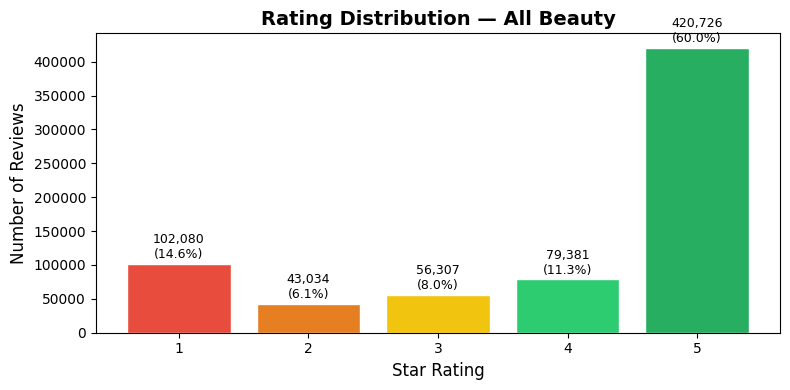


 Phase 1 complete!


In [6]:
# Rating distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
rating_counts = df_reviews["rating"].value_counts().sort_index()
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="white")
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)
ax.set_title("Rating Distribution — All Beauty", fontsize=14, fontweight="bold")
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    pct = y / len(df_reviews) * 100
    ax.text(x, y + len(df_reviews)*0.005, f"{y:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("\n Phase 1 complete!")

---
## Phase 2: Data Preprocessing
1. Clean text → 2. Sentence segmentation → 3. Create labels → 4. Train/Val/Test split

### 2.1 Clean Review Text

In [7]:
import re

def clean_text(text):
    """Remove HTML tags, URLs, and extra whitespace."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = re.sub(r"<[^>]+>", " ", text)          # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # URLs
    text = re.sub(r"\s+", " ", text).strip()       # Extra whitespace
    return text

df_reviews["text_clean"] = df_reviews["text"].apply(clean_text)

# Remove empty reviews
before = len(df_reviews)
df_reviews = df_reviews[df_reviews["text_clean"].str.len() > 0].reset_index(drop=True)
after = len(df_reviews)
print(f"Removed {before - after:,} empty reviews")
print(f"Remaining reviews: {after:,}")

Removed 731 empty reviews
Remaining reviews: 700,797


### 2.2 Sentence Segmentation with spaCy
Divided review into sentences (Time est: 10–20 mins)

In [8]:
import spacy
from tqdm.auto import tqdm

# ใช้ blank model + sentencizer (เร็วกว่า full model มาก)
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")

SENT_OUTPUT = os.path.join(DIRS["data_proc"], "sentences.jsonl")

if not os.path.exists(SENT_OUTPUT):
    sentence_count = 0
    batch_size = 10000
    num_batches = (len(df_reviews) + batch_size - 1) // batch_size

    with open(SENT_OUTPUT, "w", encoding="utf-8") as f_out:
        for batch_start in tqdm(range(0, len(df_reviews), batch_size),
                                total=num_batches, desc="Segmenting"):
            batch_end = min(batch_start + batch_size, len(df_reviews))
            batch = df_reviews.iloc[batch_start:batch_end]

            texts = batch["text_clean"].tolist()
            docs = list(nlp.pipe(texts, batch_size=512))

            for doc, (_, row) in zip(docs, batch.iterrows()):
                for sent_idx, sent in enumerate(doc.sents):
                    sent_text = sent.text.strip()
                    if len(sent_text) < 5:  # skip tiny fragments
                        continue
                    record = {
                        "sentence":     sent_text,
                        "review_rating": row["rating"],
                        "parent_asin":  row["parent_asin"],
                        "asin":         row.get("asin", ""),
                        "user_id":      row["user_id"],
                        "helpful_vote": row.get("helpful_vote", 0),
                        "verified_purchase": row.get("verified_purchase", False),
                        "sent_idx":     sent_idx,
                    }
                    f_out.write(json.dumps(record) + "\n")
                    sentence_count += 1

    print(f"\nTotal sentences: {sentence_count:,}")
    print(f"Saved to: {SENT_OUTPUT}")
else:
    sentence_count = sum(1 for _ in open(SENT_OUTPUT))
    print(f"Already exists: {SENT_OUTPUT}")
    print(f"Total sentences: {sentence_count:,}")

Already exists: /content/drive/MyDrive/NLP_Project/data/processed/sentences.jsonl
Total sentences: 1,991,664


### 2.3 Create Sentiment Labels
- 4–5 stars → **Pro** (label = 1)
- 1–2 stars → **Con** (label = 0)
- 3 stars → **remove** (Ambiguous)

In [9]:
print("Loading sentences...")
sentences = load_jsonl(SENT_OUTPUT)
df_sent = pd.DataFrame(sentences)
print(f"Total sentences: {len(df_sent):,}")

# Create labels (exclude 3-star)
df_sent_labeled = df_sent[df_sent["review_rating"] != 3.0].copy()
df_sent_labeled["label"] = (df_sent_labeled["review_rating"] >= 4.0).astype(int)

n_pro = (df_sent_labeled["label"] == 1).sum()
n_con = (df_sent_labeled["label"] == 0).sum()
print(f"\nAfter excluding 3-star: {len(df_sent_labeled):,}")
print(f"  Pro (4-5★): {n_pro:>10,}  ({n_pro/len(df_sent_labeled)*100:.1f}%)")
print(f"  Con (1-2★): {n_con:>10,}  ({n_con/len(df_sent_labeled)*100:.1f}%)")
print(f"  Imbalance ratio (Pro/Con): {n_pro/n_con:.1f}x")

Loading sentences...
Total sentences: 1,991,664

After excluding 3-star: 1,825,333
  Pro (4-5★):  1,420,926  (77.8%)
  Con (1-2★):    404,407  (22.2%)
  Imbalance ratio (Pro/Con): 3.5x


### 2.4 Train / Validation / Test Split (80/10/10)
- Stratified by label
- sentences from the same review will be in the same partition (no leakage)

In [10]:
from sklearn.model_selection import train_test_split

# Group sentences by review (user + product)
df_sent_labeled["review_key"] = (
    df_sent_labeled["user_id"] + "_" + df_sent_labeled["parent_asin"]
)

# Get unique review keys with label
review_labels = (
    df_sent_labeled.groupby("review_key")["label"]
    .first()
    .reset_index()
)

# Split 1: train (80%) vs temp (20%)
keys_train, keys_temp = train_test_split(
    review_labels["review_key"],
    test_size=0.2,
    random_state=SEED,
    stratify=review_labels["label"]
)

# Split 2: temp → val (10%) + test (10%)
temp_labels = review_labels[review_labels["review_key"].isin(keys_temp)]
keys_val, keys_test = train_test_split(
    temp_labels["review_key"],
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels["label"]
)

# Assign splits
df_sent_labeled["split"] = "train"
df_sent_labeled.loc[
    df_sent_labeled["review_key"].isin(keys_val), "split"
] = "val"
df_sent_labeled.loc[
    df_sent_labeled["review_key"].isin(keys_test), "split"
] = "test"

print("Split results:")
for s in ["train", "val", "test"]:
    n = (df_sent_labeled["split"] == s).sum()
    pct = n / len(df_sent_labeled) * 100
    print(f"  {s:>5}: {n:>10,} sentences ({pct:.1f}%)")

# Save to Drive
LABELED_FILE = os.path.join(DIRS["data_proc"], "sentences_labeled.parquet")
df_sent_labeled.to_parquet(LABELED_FILE, index=False)
print(f"\nSaved to: {LABELED_FILE}")
print("\n Phase 2 complete!")

Split results:
  train:  1,461,057 sentences (80.0%)
    val:    182,652 sentences (10.0%)
   test:    181,624 sentences (10.0%)

Saved to: /content/drive/MyDrive/NLP_Project/data/processed/sentences_labeled.parquet

 Phase 2 complete!


---
## Phase 3: Train CNN Sentiment Classifier
Yoon Kim (2014) architecture: Embedding → Conv1D (3,4,5) → MaxPool → FC

### 3.1 Build Vocabulary

In [11]:
from collections import Counter

# Reload if needed (e.g., after Colab reconnects)
# df_sent_labeled = pd.read_parquet(LABELED_FILE)

df_train = df_sent_labeled[df_sent_labeled["split"] == "train"]
df_val   = df_sent_labeled[df_sent_labeled["split"] == "val"]
df_test  = df_sent_labeled[df_sent_labeled["split"] == "test"]

def tokenize(text):
    """Simple lowercase whitespace tokenizer."""
    return text.lower().split()

# Count word frequencies (training set only)
word_counts = Counter()
for text in df_train["sentence"]:
    word_counts.update(tokenize(text))

# Vocab: words with freq >= 2
MIN_FREQ = 2
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}  (min freq = {MIN_FREQ})")

Vocabulary size: 90,426  (min freq = 2)


### 3.2 Download & Load GloVe 300d or BLAIR (Select one)

In [17]:
GLOVE_FILE = os.path.join(DIRS["embeddings"], "glove.6B.300d.txt")
EMBED_DIM  = 300

# Download GloVe (save in Drive, no need to re-download)
if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe 6B... (~862 MB, Time est: 2-5 mins)")
    !wget -q https://nlp.stanford.edu/data/glove.6B.zip -O /tmp/glove.6B.zip
    !unzip -q -j /tmp/glove.6B.zip glove.6B.300d.txt -d {DIRS['embeddings']}
    !rm /tmp/glove.6B.zip
    print("Done!")
else:
    print(f"GloVe already exists: {GLOVE_FILE}")

# Load only words in our vocab
print("Loading GloVe vectors...")
glove_vectors = {}
with open(GLOVE_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        if word in vocab:
            glove_vectors[word] = np.array(parts[1:], dtype=np.float32)

# Create embedding matrix
embedding_matrix = np.random.uniform(
    -0.25, 0.25, (VOCAB_SIZE, EMBED_DIM)
).astype(np.float32)
embedding_matrix[0] = np.zeros(EMBED_DIM)  # <PAD>

matched = 0
for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        matched += 1

print(f"GloVe coverage: {matched:,} / {VOCAB_SIZE:,} ({matched/VOCAB_SIZE*100:.1f}%)")
del glove_vectors  # free memory

GloVe already exists: /content/drive/MyDrive/NLP_Project/data/embeddings/glove.6B.300d.txt
Loading GloVe vectors...
GloVe coverage: 29,789 / 90,426 (32.9%)


In [12]:
# Cell 3.2b: Create BLAIR embedding matrix for vocabulary

from transformers import AutoTokenizer, AutoModel
import torch

print("Loading BLAIR model...")
BLAIR_MODEL = "hyp1231/blair-roberta-base"
blair_tokenizer = AutoTokenizer.from_pretrained(BLAIR_MODEL)
blair_model     = AutoModel.from_pretrained(BLAIR_MODEL).to(DEVICE)
blair_model.eval()

print(f"Creating BLAIR embeddings for {VOCAB_SIZE:,} words...")
print("(อาจใช้เวลา 10-20 นาที)")

BLAIR_DIM = 768
blair_matrix = np.zeros((VOCAB_SIZE, BLAIR_DIM), dtype=np.float32)

# encode ทีละ batch
WORDS       = list(vocab.keys())
BATCH_SIZE_BLAIR = 256

with torch.no_grad():
    for i in range(0, len(WORDS), BATCH_SIZE_BLAIR):
        batch_words = WORDS[i:i + BATCH_SIZE_BLAIR]

        encoded = blair_tokenizer(
            batch_words,
            padding=True,
            truncation=True,
            max_length=8,       # แต่ละคำสั้นมาก
            return_tensors="pt"
        ).to(DEVICE)

        outputs = blair_model(**encoded)
        # ใช้ CLS token เป็น word embedding
        embeddings = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

        for j, word in enumerate(batch_words):
            idx = vocab[word]
            blair_matrix[idx] = embeddings[j].cpu().numpy()

        if (i // BATCH_SIZE_BLAIR) % 20 == 0:
            print(f"  {min(i+BATCH_SIZE_BLAIR, len(WORDS)):,} / {len(WORDS):,} words")

# <PAD> = zero vector
blair_matrix[0] = np.zeros(BLAIR_DIM)

print("BLAIR embedding matrix created!")
print(f"Shape: {blair_matrix.shape}")

# free GPU memory
blair_model.cpu()
torch.cuda.empty_cache()

Loading BLAIR model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Creating BLAIR embeddings for 90,426 words...
(อาจใช้เวลา 10-20 นาที)
  256 / 90,426 words
  5,376 / 90,426 words
  10,496 / 90,426 words
  15,616 / 90,426 words
  20,736 / 90,426 words
  25,856 / 90,426 words
  30,976 / 90,426 words
  36,096 / 90,426 words
  41,216 / 90,426 words
  46,336 / 90,426 words
  51,456 / 90,426 words
  56,576 / 90,426 words
  61,696 / 90,426 words
  66,816 / 90,426 words
  71,936 / 90,426 words
  77,056 / 90,426 words
  82,176 / 90,426 words
  87,296 / 90,426 words
BLAIR embedding matrix created!
Shape: (90426, 768)


### 3.3 PyTorch Dataset & DataLoader

In [13]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 128  # tokens per sentence

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts  = texts
        self.labels = labels
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens  = tokenize(self.texts[idx])[:self.max_len]
        indices = [self.vocab.get(t, 1) for t in tokens]  # 1 = <UNK>
        padding = [0] * (self.max_len - len(indices))
        indices = indices + padding
        return (
            torch.tensor(indices, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float),
        )

train_dataset = SentimentDataset(df_train["sentence"].tolist(), df_train["label"].tolist(), vocab)
val_dataset   = SentimentDataset(df_val["sentence"].tolist(),   df_val["label"].tolist(),   vocab)
test_dataset  = SentimentDataset(df_test["sentence"].tolist(),  df_test["label"].tolist(),  vocab)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset):>10,} sentences  ({len(train_loader):,} batches)")
print(f"Val:   {len(val_dataset):>10,} sentences  ({len(val_loader):,} batches)")
print(f"Test:  {len(test_dataset):>10,} sentences  ({len(test_loader):,} batches)")

Train:  1,461,057 sentences  (22,830 batches)
Val:      182,652 sentences  (2,854 batches)
Test:     181,624 sentences  (2,838 batches)


### 3.4 CNN Model — Yoon Kim (2014)

In [14]:
import torch.nn as nn

class TextCNN(nn.Module):
    """
    CNN for Sentiment Classification (Yoon Kim, 2014)

    Embedding → Conv1D (kernel 3,4,5) × 100 filters each
    → ReLU → Max-over-time pooling → Dropout(0.5) → FC → Sigmoid
    """
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes,
                 dropout, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.tensor(pretrained_embeddings)
            )
            self.embedding.weight.requires_grad = True  # fine-tune

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        x = self.embedding(x)              # (B, L, D)
        x = x.permute(0, 2, 1)             # (B, D, L)

        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(x))         # (B, F, L-k+1)
            c = c.max(dim=2).values          # (B, F)
            conv_outs.append(c)

        cat = torch.cat(conv_outs, dim=1)   # (B, F*3)
        cat = self.dropout(cat)
        return self.fc(cat).squeeze(1)       # (B,)


### 3.5 Class-Weighted Loss & Optimizer

In [15]:
import torch.optim as optim

n_pro = (df_train["label"] == 1).sum()
n_con = (df_train["label"] == 0).sum()

# pos_weight: add more weight to con due to minority
pos_weight = torch.tensor([n_con / n_pro]).to(DEVICE)

print(f"Pro (positive): {n_pro:,}")
print(f"Con (negative): {n_con:,}")
print(f"pos_weight:     {pos_weight.item():.4f}")

Pro (positive): 1,136,975
Con (negative): 324,082
pos_weight:     0.2850


### 3.6 Training Loop (with Early Stopping) 12+ hrs

GloVe 300d embedding setting
- emb_matrix = embedding_matrix   # GloVe 300d
- emb_dim    = EMBED_DIM          # 300

Blair embedding setting  
- emb_matrix = blair_matrix       # BLAIR 768d
- emb_dim    = BLAIR_DIM

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score
from itertools import product
import time

def evaluate(model, loader, criterion, device):
    """Evaluate model and return loss, macro-F1, predictions, labels."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)

            preds = (torch.sigmoid(logits) >= 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    macro_f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels)

##### This block is for grid search

In [ ]:
# === Grid Search Config ===
GRID = {
    "kernel_sizes":  [[2,3,4], [3,4,5]],
    "num_filters":   [100, 128, 256],
    "dropout":       [0.3, 0.5],
    "learning_rate": [0.001, 0.0005, 0.0001],
}

MAX_EPOCHS = 30
PATIENCE   = 5

keys             = list(GRID.keys())
values           = list(GRID.values())
all_combinations = list(product(*values))

print(f"Total combinations: {len(all_combinations)}")
print(f"Max epochs per combination: {MAX_EPOCHS} (early stopping patience={PATIENCE})")
print("=" * 80)

grid_results    = []
best_overall_f1 = 0
best_config     = None

for combo_idx, combo in enumerate(all_combinations, 1):
    config = dict(zip(keys, combo))
    print(f"\n[{combo_idx}/{len(all_combinations)}] Config: {config}")
    print("-" * 70)

    # --- create new model, criterion, optimizer in every combination ---
    model = TextCNN(
        vocab_size            = VOCAB_SIZE,
        embed_dim             = EMBED_DIM,
        # embed_dim             = BLAIR_DIM,
        num_filters           = config["num_filters"],
        kernel_sizes          = config["kernel_sizes"],
        dropout               = config["dropout"],
        pretrained_embeddings = embedding_matrix,
        # pretrained_embeddings = blair_matrix,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

    # --- Reset in every combination ---
    best_val_f1      = 0
    patience_counter = 0
    MODEL_PATH_TMP   = os.path.join(DIRS["models"], "cnn_tmp.pt")
    history_combo    = {"train_loss": [], "val_loss": [], "val_f1": []}

    print(f"  {'Epoch':>5} │ {'Train Loss':>10} │ {'Val Loss':>10} │ "
          f"{'Val F1':>8} │ {'Time':>6} │ Status")
    print("  " + "─" * 60)

    # --- Epoch loop ---
    for epoch in range(1, MAX_EPOCHS + 1):
        t0 = time.time()

        # Train
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(inputs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(labels)

        avg_train_loss = train_loss / len(train_loader.dataset)

        # Validate
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        history_combo["train_loss"].append(avg_train_loss)
        history_combo["val_loss"].append(val_loss)
        history_combo["val_f1"].append(val_f1)

        elapsed = time.time() - t0

        # Early stopping
        status = ""
        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_PATH_TMP)
            status = "★ saved"
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                status = "STOP"

        print(f"  {epoch:>5} │ {avg_train_loss:>10.4f} │ {val_loss:>10.4f} │ "
              f"{val_f1:>8.4f} │ {elapsed:>5.1f}s │ {status}")

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

    # --- save this config ---
    grid_results.append({
        "kernel_sizes":  str(config["kernel_sizes"]),
        "num_filters":   config["num_filters"],
        "dropout":       config["dropout"],
        "learning_rate": config["learning_rate"],
        "best_val_f1":   round(best_val_f1, 4),
        "epochs_run":    len(history_combo["train_loss"]),
    })

    print(f"\n  → Best Val F1 for this config: {best_val_f1:.4f}")

    # --- Collect best overall ---
    if best_val_f1 > best_overall_f1:
        best_overall_f1 = best_val_f1
        best_config     = config
        torch.save(
            model.state_dict(),
            os.path.join(DIRS["models"], "cnn_best_grid_glove300.pt")
        )
        print(f"  ★ New best overall! Saved to cnn_best_grid_glove300.pt")

# === Grid Search Summary ===
print("\n" + "=" * 80)
print("GRID SEARCH RESULTS")
print("=" * 80)
results_df = pd.DataFrame(grid_results).sort_values("best_val_f1", ascending=False)
print(results_df.to_string(index=False))

print(f"\nBest config:    {best_config}")
print(f"Best Val F1:    {best_overall_f1:.4f}")

# Save grid results to Drive
grid_path = os.path.join(DIRS["results"], "grid_search_results.csv")
results_df.to_csv(grid_path, index=False)
print(f"\nSaved grid results to: {grid_path}")

Total combinations: 36
Max epochs per combination: 30 (early stopping patience=5)

[1/36] Config: {'kernel_sizes': [2, 3, 4], 'num_filters': 100, 'dropout': 0.3, 'learning_rate': 0.001}
----------------------------------------------------------------------
  Epoch │ Train Loss │   Val Loss │   Val F1 │   Time │ Status
  ────────────────────────────────────────────────────────────
      1 │     0.1703 │     0.1596 │   0.8174 │ 117.9s │ ★ saved
      2 │     0.1475 │     0.1523 │   0.8104 │ 117.3s │ 
      3 │     0.1359 │     0.1531 │   0.8112 │ 116.8s │ 
      4 │     0.1259 │     0.1637 │   0.8253 │ 116.4s │ ★ saved
      5 │     0.1172 │     0.1620 │   0.8098 │ 117.1s │ 
      6 │     0.1095 │     0.1689 │   0.8021 │ 116.0s │ 
      7 │     0.1029 │     0.1789 │   0.8103 │ 116.9s │ 
      8 │     0.0974 │     0.1819 │   0.7970 │ 117.9s │ 
      9 │     0.0929 │     0.1970 │   0.8141 │ 116.7s │ STOP
  Early stopping at epoch 9

  → Best Val F1 for this config: 0.8253
  ★ New best over

##### This block for run selected model

In [17]:
NUM_FILTERS   = 100
KERNEL_SIZES  = [3, 4, 5]
DROPOUT       = 0.5
LEARNING_RATE = 0.001

model = TextCNN(
    vocab_size  = VOCAB_SIZE,
    # embed_dim   = EMBED_DIM, #glove
    embed_dim   = BLAIR_DIM,
    num_filters = NUM_FILTERS,
    kernel_sizes= KERNEL_SIZES,
    dropout     = DROPOUT,
    # pretrained_embeddings = embedding_matrix, #glove
    pretrained_embeddings = blair_matrix,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 70,369,369
TextCNN(
  (embedding): Embedding(90426, 768, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(768, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(768, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(768, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)


In [18]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def evaluate(model, loader, criterion, device):
    """Evaluate model and return loss, macro-F1, predictions, labels."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)

            preds = (torch.sigmoid(logits) >= 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    macro_f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels)


# === Training config ===
MAX_EPOCHS = 30
PATIENCE   = 5
MODEL_PATH = os.path.join(DIRS["models"], "cnn_sentiment_best.pt")

best_val_f1      = 0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_f1": []}

print(f"{'Epoch':>5} │ {'Train Loss':>10} │ {'Val Loss':>10} │ "
      f"{'Val F1':>8} │ {'Time':>6} │ Status")
print("─" * 68)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    # --- Train ---
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(labels)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- Validate ---
    val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    elapsed = time.time() - t0

    # --- Early stopping ---
    status = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        status = "★ saved"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            status = "STOP"

    print(f"{epoch:>5} │ {avg_train_loss:>10.4f} │ {val_loss:>10.4f} │ "
          f"{val_f1:>8.4f} │ {elapsed:>5.1f}s │ {status}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation Macro F1: {best_val_f1:.4f}")
print(f"Model saved to: {MODEL_PATH}")

Epoch │ Train Loss │   Val Loss │   Val F1 │   Time │ Status
────────────────────────────────────────────────────────────────────
    1 │     0.1799 │     0.1617 │   0.8099 │ 190.0s │ ★ saved
    2 │     0.1616 │     0.1576 │   0.8082 │ 190.2s │ 
    3 │     0.1539 │     0.1569 │   0.8078 │ 190.1s │ 
    4 │     0.1482 │     0.1603 │   0.8074 │ 189.9s │ 
    5 │     0.1432 │     0.1607 │   0.8002 │ 190.4s │ 
    6 │     0.1390 │     0.1627 │   0.8123 │ 189.5s │ ★ saved
    7 │     0.1353 │     0.1669 │   0.8067 │ 189.2s │ 
    8 │     0.1319 │     0.1696 │   0.8110 │ 189.2s │ 
    9 │     0.1288 │     0.1736 │   0.8085 │ 190.8s │ 
   10 │     0.1258 │     0.1778 │   0.8187 │ 189.8s │ ★ saved
   11 │     0.1232 │     0.1762 │   0.8051 │ 189.2s │ 
   12 │     0.1208 │     0.1780 │   0.7920 │ 190.0s │ 
   13 │     0.1189 │     0.1913 │   0.8133 │ 190.0s │ 
   14 │     0.1168 │     0.1848 │   0.8042 │ 190.0s │ 
   15 │     0.1152 │     0.1863 │   0.8013 │ 189.7s │ STOP

Early stopping at e

### 3.7 Training Curves

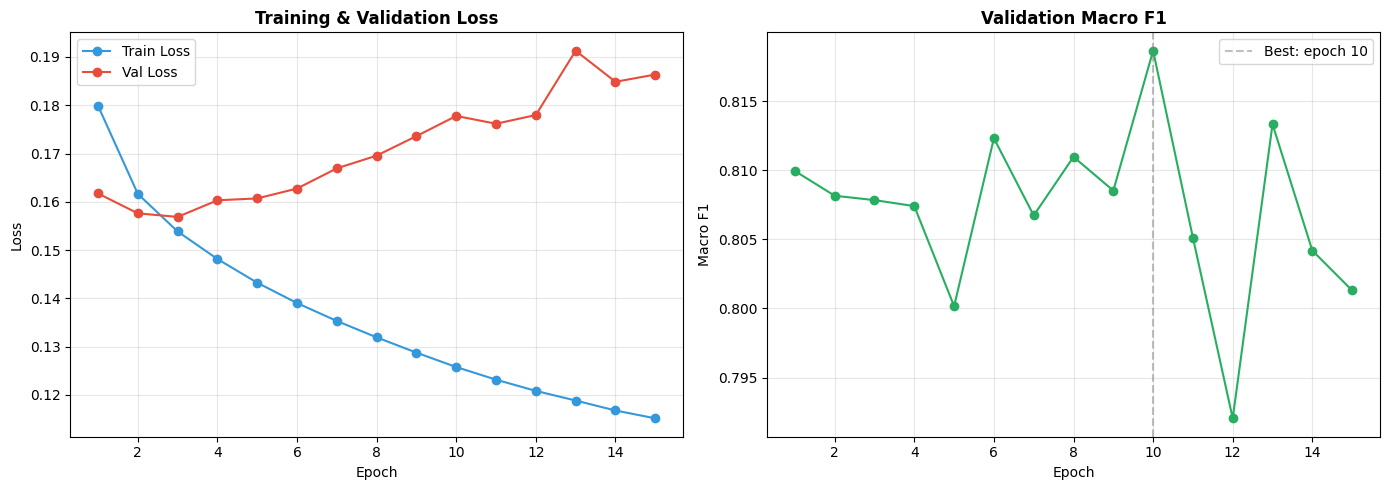

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

# Loss
ax1.plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#3498db")
ax1.plot(epochs, history["val_loss"],   "o-", label="Val Loss",   color="#e74c3c")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1
ax2.plot(epochs, history["val_f1"], "o-", color="#27ae60")
best_epoch = np.argmax(history["val_f1"]) + 1
ax2.axvline(x=best_epoch, color="gray", linestyle="--", alpha=0.5, label=f"Best: epoch {best_epoch}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.set_title("Validation Macro F1", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["results"], "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.8 Test Set Evaluation

Test Loss:     0.1763
Test Macro F1: 0.8198

Classification Report
              precision    recall  f1-score   support

  Con (1-2★)     0.6754    0.7843    0.7258     40177
  Pro (4-5★)     0.9358    0.8929    0.9139    141447

    accuracy                         0.8689    181624
   macro avg     0.8056    0.8386    0.8198    181624
weighted avg     0.8782    0.8689    0.8723    181624



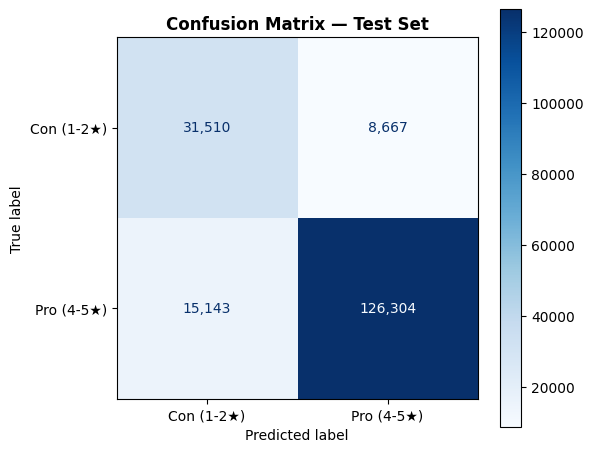

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
test_loss, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print(f"\n{'='*50}")
print("Classification Report")
print(f"{'='*50}")
print(classification_report(
    test_labels, test_preds,
    target_names=["Con (1-2★)", "Pro (4-5★)"],
    digits=4
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Con (1-2★)", "Pro (4-5★)"])
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DIRS["results"], "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.9 Confidence Threshold Calibration
finding the optimal threshold: lower than threshold collect both pro pool and con pool

In [21]:
# Get probabilities on validation set
model.eval()
all_probs, all_labels_val = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        logits = model(inputs)
        probs  = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels_val.extend(labels.numpy())

all_probs      = np.array(all_probs)
all_labels_val = np.array(all_labels_val)

# Sweep thresholds
print(f"{'Threshold':>10} │ {'Both Pools %':>12} │ {'Prec Pro':>9} │ "
      f"{'Prec Con':>9} │ {'Min Prec':>9}")
print("─" * 60)

best_threshold = 0.70
best_score     = 0

for threshold in np.arange(0.50, 0.91, 0.05):
    confidence = np.maximum(all_probs, 1 - all_probs)
    both_pct   = (confidence < threshold).mean() * 100

    above = confidence >= threshold
    if above.sum() > 0:
        preds_a  = (all_probs[above] >= 0.5).astype(int)
        labels_a = all_labels_val[above].astype(int)
        prec_pro = precision_score(labels_a, preds_a, pos_label=1, zero_division=0)
        prec_con = precision_score(labels_a, preds_a, pos_label=0, zero_division=0)
        min_prec = min(prec_pro, prec_con)
    else:
        prec_pro = prec_con = min_prec = 0

    marker = ""
    if min_prec >= 0.75 and both_pct > best_score:
        best_score     = both_pct
        best_threshold = threshold
        marker = " ◄"

    print(f"{threshold:>10.2f} │ {both_pct:>11.1f}% │ {prec_pro:>9.4f} │ "
          f"{prec_con:>9.4f} │ {min_prec:>9.4f}{marker}")

print(f"\n Selected threshold: {best_threshold:.2f}")

 Threshold │ Both Pools % │  Prec Pro │  Prec Con │  Min Prec
────────────────────────────────────────────────────────────
      0.50 │         0.0% │    0.9357 │    0.6731 │    0.6731
      0.55 │         4.2% │    0.9421 │    0.7006 │    0.7006
      0.60 │         8.7% │    0.9490 │    0.7258 │    0.7258
      0.65 │        12.8% │    0.9539 │    0.7502 │    0.7502 ◄
      0.70 │        16.8% │    0.9582 │    0.7733 │    0.7733 ◄
      0.75 │        21.0% │    0.9626 │    0.7944 │    0.7944 ◄
      0.80 │        25.8% │    0.9669 │    0.8164 │    0.8164 ◄
      0.85 │        31.3% │    0.9713 │    0.8398 │    0.8398 ◄
      0.90 │        38.4% │    0.9766 │    0.8669 │    0.8669 ◄

 Selected threshold: 0.90


### 3.10 Save All Results

In [22]:
results = {
    "model": "TextCNN (Yoon Kim, 2014)",
    "hyperparameters": {
        "kernel_sizes": KERNEL_SIZES,
        "num_filters":  NUM_FILTERS,
        "dropout":      DROPOUT,
        "learning_rate": LEARNING_RATE,
        "batch_size":   BATCH_SIZE,
        "max_len":      MAX_LEN,
        "embedding":    "GloVe 300d",
    },
    "training": {
        "epochs_run":      len(history["train_loss"]),
        "best_val_f1":     best_val_f1,
        "early_stopping":  PATIENCE,
    },
    "test_results": {
        "test_loss":     test_loss,
        "test_macro_f1": test_f1,
        "report": classification_report(
            test_labels, test_preds,
            target_names=["Con", "Pro"],
            output_dict=True
        ),
    },
    "confidence_threshold": best_threshold,
    "data_stats": {
        "vocab_size":  VOCAB_SIZE,
        "train_size":  len(df_train),
        "val_size":    len(df_val),
        "test_size":   len(df_test),
    },
}

# Save results JSON
results_path = os.path.join(DIRS["results"], "phase3_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

# Save training history
history_path = os.path.join(DIRS["results"], "training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

print("Saved files:")
print(f"  Model:    {MODEL_PATH}")
print(f"  Results:  {results_path}")
print(f"  History:  {history_path}")
print(f"  Curves:   {DIRS['results']}/training_curves.png")
print(f"  CM:       {DIRS['results']}/confusion_matrix.png")

Saved files:
  Model:    /content/drive/MyDrive/NLP_Project/models/cnn_sentiment_best.pt
  Results:  /content/drive/MyDrive/NLP_Project/results/phase3_results.json
  History:  /content/drive/MyDrive/NLP_Project/results/training_history.json
  Curves:   /content/drive/MyDrive/NLP_Project/results/training_curves.png
  CM:       /content/drive/MyDrive/NLP_Project/results/confusion_matrix.png


### 3.11 Quick Sanity Check — ลองทดสอบกับประโยคจริง

In [23]:
def predict_sentiment(text, model, vocab, device, threshold=0.5):
    """Predict sentiment for a single sentence."""
    model.eval()
    tokens  = tokenize(text)[:MAX_LEN]
    indices = [vocab.get(t, 1) for t in tokens]
    indices += [0] * (MAX_LEN - len(indices))
    x = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        logit = model(x)
        prob  = torch.sigmoid(logit).item()

    confidence = max(prob, 1 - prob)
    label = "Pro" if prob >= threshold else "Con"
    return label, prob, confidence


# ทดสอบกับตัวอย่างประโยค
test_sentences = [
    "This shampoo makes my hair incredibly soft and shiny",
    "Terrible product, caused severe irritation on my scalp",
    "The scent is nice but it left my hair feeling dry",
    "Best moisturizer I have ever used, totally worth the price",
    "Broke out in hives after using this, would not recommend",
    "It's okay, nothing special but does the job",
]

print(f"{'Sentence':<55} │ {'Pred':>4} │ {'Prob':>5} │ {'Conf':>5}")
print("─" * 80)
for s in test_sentences:
    label, prob, conf = predict_sentiment(s, model, vocab, DEVICE)
    short = s[:52] + "..." if len(s) > 55 else s
    print(f"{short:<55} │ {label:>4} │ {prob:>5.3f} │ {conf:>5.3f}")

Sentence                                                │ Pred │  Prob │  Conf
────────────────────────────────────────────────────────────────────────────────
This shampoo makes my hair incredibly soft and shiny    │  Pro │ 0.943 │ 0.943
Terrible product, caused severe irritation on my scalp  │  Con │ 0.002 │ 0.998
The scent is nice but it left my hair feeling dry       │  Con │ 0.073 │ 0.927
Best moisturizer I have ever used, totally worth the... │  Pro │ 1.000 │ 1.000
Broke out in hives after using this, would not recom... │  Con │ 0.000 │ 1.000
It's okay, nothing special but does the job             │  Pro │ 0.647 │ 0.647


---
## Summary

| Item | Value |
|------|-------|
| Model | TextCNN (Yoon Kim, 2014) |
| Kernels | (3, 4, 5) × 100 filters |
| Embedding | GloVe 300d |
| Dropout | 0.5 |
| Loss | BCEWithLogitsLoss + class weight |
| Early stopping | patience = 5 on val Macro F1 |

**ทุกอย่างถูกบันทึกไว้ใน Google Drive** ดังนั้นแม้ Colab disconnect ก็ไม่ต้องเริ่มใหม่

### Next Steps
- **Phase 4:** BLAIR Encoding + FAISS Vector Database
- **Phase 5:** BiLSTM Clarification Classifier
- **Phase 6:** BiLSTM Extractive Summarizer

---
### Utility: Resume After Colab Disconnects
ถ้า Colab หลุดระหว่างทาง ให้รัน cell นี้เพื่อ load ข้อมูลกลับมา

In [ ]:
# === UNCOMMENT AND RUN THIS CELL TO RESUME ===

# from google.colab import drive
# drive.mount('/content/drive')

# PROJECT_ROOT = "/content/drive/MyDrive/NLP_Project"
# DIRS = {
#     "data_raw":   f"{PROJECT_ROOT}/data/raw",
#     "data_proc":  f"{PROJECT_ROOT}/data/processed",
#     "models":     f"{PROJECT_ROOT}/models",
#     "results":    f"{PROJECT_ROOT}/results",
#     "embeddings": f"{PROJECT_ROOT}/data/embeddings",
# }

# import pandas as pd
# LABELED_FILE = f"{DIRS['data_proc']}/sentences_labeled.parquet"
# df_sent_labeled = pd.read_parquet(LABELED_FILE)
# print(f"Loaded {len(df_sent_labeled):,} labeled sentences")
# print("Now you can continue from Phase 3 (step 3.1)")